# Desafio 4: Modelo Sec2Sec para traduccion de texto
## Alumno: Maxim Dorogov

### Consigna
- Implementar un modelo sec2sec para traducción de texto utilizando la librería PyTorch.

- Para los embeddings usar capas pre entrenadas como GloVe o FastText.

In [6]:
import pandas as pd
import numpy as np

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences

import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary

from matplotlib import pyplot as plt

from tqdm import tqdm
from typing import Dict

Leemos y parseamos el archivo con pares de oraciones en ingles y español.

In [31]:
DATA_FILE = './spa-eng/spa.txt'
N_ROWS = 80000
# read only N first lines for faster testing
data = pd.read_csv(
    DATA_FILE, sep='\t', header=None, names=['eng', 'spa', 'other'], nrows=N_ROWS)
data = data[['eng', 'spa']]
print(f'Dataset size: {len(data)} pairs of sentences')
data.tail()


Dataset size: 80000 pairs of sentences


,eng,spa
79995,I don't think you're heartless.,No pienso que seas un desalmado.
79996,I don't totally agree with you.,No estoy totalmente de acuerdo contigo.
79997,I don't trust talkative people.,No confío en la gente habladora.
79998,I don't understand any of this.,No entiendo nada de esto.
79999,I don't understand the problem.,No entiendo el problema.


EL input sera la oracion en espanol y el output la oracion en ingles. Agregamos tokens de inicio y fin de secuencia.

In [32]:
data['input_raw'] = data['spa']
data['decoder_output'] = data['eng'] + ' <eos>'
data['decoder_input'] = '<sos> ' + data['eng']
data.head()

,eng,spa,input_raw,decoder_output,decoder_input
0,Go.,Ve.,Ve.,Go. <eos>,<sos> Go.
1,Go.,Vete.,Vete.,Go. <eos>,<sos> Go.
2,Go.,Vaya.,Vaya.,Go. <eos>,<sos> Go.
3,Go.,Váyase.,Váyase.,Go. <eos>,<sos> Go.
4,Hi.,Hola.,Hola.,Hi. <eos>,<sos> Hi.


### Preprocesamiento de datos

Tokenizamos y preparamos las secuencias de entrada y salida.

In [ ]:
MAX_VOCAB_SIZE = 10000

### Input Tokenizer

input_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE, 
    filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n')

input_tokenizer.fit_on_texts(data['input_raw'])
input_seq = input_tokenizer.texts_to_sequences(data['input_raw'])

word2idx_inputs = input_tokenizer.word_index
max_input_len = max(len(sen) for sen in input_seq)
print("Palabras en el vocabulario de entrada:", len(word2idx_inputs))
print("Sentencia de entrada más larga:", max_input_len)

### Output Tokenizer

output_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE, 
    filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n')

# Fit the tokenizer on the decoder input and output texts (including <sos> and <eos>)
output_tokenizer.fit_on_texts(
    data['decoder_input'].tolist() +
    data['decoder_output'].tolist())
decoder_output_seq = output_tokenizer.texts_to_sequences(data['decoder_output'])
decoder_input_seq = output_tokenizer.texts_to_sequences(data['decoder_input'])

num_words_output = min(MAX_VOCAB_SIZE, len(output_tokenizer.word_index) + 1)
word2idx_outputs = output_tokenizer.word_index

max_output_len = max(len(sen) for sen in decoder_input_seq)
print("Palabras en el vocabulario de salida:", len(word2idx_outputs))
print("Sentencia de salida más larga:", max_output_len)

Calculamos el coverage del vocabulario para ver si el tamaño elegido es adecuado.
Iteramos sobre el valor de MAX_VOCAB_SIZE hasta ajustarlo al coverage deseado.
La idea es cubrir al menos el 95% del vocabulario con las palabras mas frecuentes.

In [34]:
# check actual coverage
sorted_items = sorted(
    input_tokenizer.word_counts.items(), key=lambda kv: kv[1], reverse=True)
total = sum(input_tokenizer.word_counts.values())
covered = sum(
    [count for _, count in sorted_items[:MAX_VOCAB_SIZE]])
coverage = covered / total
print(f"Vocab coverage: {coverage:.2%}")

Vocab coverage: 97.56%


Agregamos padding a las secuencias para que todas tengan la misma longitud.
>NOTA: Tener en cuenta que en el encoder los ceros se agregan al comienzo y en el decoder al final. Esto es porque la salida del encoder está basada en las últimas palabras de la sentencia (son las más importantes), mientras que en el decoder está basada en el comienzo de la secuencia de salida ya que es la realimentación del sistema y termina con fin de sentencia.

In [ ]:
max_input_len = 16
max_out_len = 12

encoder_input_sequences = pad_sequences(input_seq, maxlen=max_input_len)

decoder_input_sequences = pad_sequences(
    decoder_input_seq, maxlen=max_out_len, padding='post')

decoder_output_sequences = pad_sequences(
    decoder_output_seq, maxlen=max_out_len, padding='post')
decoder_targets = decoder_output_sequences


### Embeddings pre entrenados

In [36]:
class GloveEmbeddings:

    def __init__(self, path: str):

        self.embeddings = self._load_glove_embeddings(path)
        # build the vocabulary hashmap
        index = np.arange(len(self.embeddings))
        # Dicctionarios para traducir de embedding a IDX de la palabra
        self.word2idx = dict(zip(self.embeddings.keys(), index))
        self.idx2word = dict(zip(index, self.embeddings.keys()))
        self._n_features = len(list(self.embeddings.values())[1])

    @staticmethod
    def _load_glove_embeddings(filepath: str) -> Dict[str, np.ndarray]:
        """
        Loads GloVe word embeddings from a file and stores them in a dictionary.

        Args:
            filepath (str): The path to the GloVe .vec file.

        Returns:
            dict: A dictionary mapping words to their corresponding numpy vector arrays.
        """
        embeddings_dict = {}
        
        with open(filepath, 'r', encoding='utf-8') as f:
            for line in f:
                
                # Split the line into word and vector values
                values = line.split()

                word = values[0]
                if word.isnumeric():  # skip numeric-only "words"
                    continue
                # if some malformed line, skip it
                try:
                    vector = np.asarray(values[1:], dtype='float32')
                except ValueError:
                    continue
                embeddings_dict[word] = vector

        print(f"Loaded {len(embeddings_dict)} word vectors.")
        return embeddings_dict

    def get_words_embeddings(self, words):
        return np.array([
            self.embeddings.get(word, np.zeros(self._n_features)) for word in words])

    def words2idxs(self, words):
        return np.array([self.word2idx.get(word, -1) for word in words])

    def idxs2words(self, idxs):
        return np.array([self.idx2word.get(idx, '-1') for idx in idxs])

Usamos GloVe en español e inglés. Los ebeddings en español son de 300 dimensiones y los de inglés de 50 dimensiones.

>NOTA: Los archivos de embeddings son pesados, por lo que no los subo al repositorio. Se pueden descargar de los siguientes links:
- Inglés: https://nlp.stanford.edu/data/wordvecs/glove.2024.wikigiga.50d.zip
- Español: https://github.com/dccuchile/spanish-word-embeddings#glove-embeddings-from-sbwc

In [37]:
spanish_emb = GloveEmbeddings("./glove-sbwc.i25.vec")
english_emb = GloveEmbeddings("./glove.2024.wikigiga.50d/wiki_giga_2024_50_MFT20_vectors_seed_123_alpha_0.75_eta_0.075_combined.txt")

Loaded 855339 word vectors.
Loaded 1277237 word vectors.


Armo las matrices de embeddings para el encoder y decoder usando los embeddings pre entrenados.

In [38]:
def create_embedding_matrix(
    glove_embeddings, word2index, max_vocab_size):
    """
    Create an embedding matrix for the given tokenizer using pre-trained GloVe embeddings.
    """
    embedding_matrix = np.zeros((max_vocab_size, glove_embeddings._n_features))
    for word, i in word2index.items():
        if i >= max_vocab_size:
            continue
        embedding_vector = glove_embeddings.get_words_embeddings([word])[0]
        embedding_matrix[i] = embedding_vector
    return embedding_matrix

In [39]:
spanish_emb_matrix = create_embedding_matrix(
    spanish_emb, word2idx_inputs, MAX_VOCAB_SIZE)

english_emb_matrix = create_embedding_matrix(
    english_emb, word2idx_outputs, MAX_VOCAB_SIZE)

print("Spanish embedding matrix shape:", spanish_emb_matrix.shape)
print("English embedding matrix shape:", english_emb_matrix.shape)

Spanish embedding matrix shape: (10000, 300)
English embedding matrix shape: (10000, 50)


### Arquitectura del modelo

In [ ]:
class Encoder(nn.Module):
    def __init__(
        self, 
        vocab_size, 
        embedding_matrix, 
        lstm_layers=1, 
        lstm_hidden_size=64,
        dropout=0.1):
        super().__init__()

        self.embedding_dim = embedding_matrix.shape[1]
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size, 
            embedding_dim=self.embedding_dim, 
            padding_idx=0)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        self.embedding.weight.requires_grad = False # freeze embedding layer

        self.lstm = nn.LSTM(
            input_size=self.embedding_dim,
            hidden_size=lstm_hidden_size, 
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0,
            num_layers=lstm_layers)

    def forward(self, x):
        out = self.embedding(x)
        _, (ht, ct) = self.lstm(out)
        return (ht, ct)

class Decoder(nn.Module):
    def __init__(
        self, 
        vocab_size, 
        embedding_matrix, 
        lstm_layers=1, 
        lstm_hidden_size=64,
        dropout=0.1):
        super().__init__()

        self.embedding_dim = embedding_matrix.shape[1]
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size, 
            embedding_dim=self.embedding_dim, 
            padding_idx=0)
        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        self.embedding.weight.requires_grad = False # freeze embedding layer

        self.lstm = nn.LSTM(
            input_size=self.embedding_dim,
            hidden_size=lstm_hidden_size, 
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0,
            num_layers=lstm_layers)
        self.fc = nn.Linear(lstm_hidden_size, vocab_size)

    def forward(self, x, hidden):
        x = self.embedding(x)
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out)
        return out, hidden

class Seq2Seq(nn.Module):
    def __init__(
        self, 
        encoder: Encoder, 
        decoder: Decoder
    ):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, trg):
        batch_size, trg_len = trg.shape
        vocab_size = self.decoder.fc.out_features

        outputs = torch.zeros(batch_size, trg_len, vocab_size)

        hidden = self.encoder(src)

        input = trg[:, 0].unsqueeze(1)  # first input to the decoder is the <sos> token

        for t in range(1, trg_len):
            output, hidden = self.decoder(input, hidden)
            outputs[:, t] = output.squeeze(1)
            top1 = output.argmax(2)
            input = top1  # teacher forcing
        return outputs

In [41]:
encoder = Encoder(
    vocab_size=MAX_VOCAB_SIZE,
    embedding_matrix=spanish_emb_matrix,
    lstm_layers=2,
    lstm_hidden_size=128)
decoder = Decoder(
    vocab_size=MAX_VOCAB_SIZE,
    embedding_matrix=english_emb_matrix,
    lstm_layers=2,
    lstm_hidden_size=128)
seq2seq = Seq2Seq(encoder, decoder)

summary(seq2seq, input_data=[
    torch.randint(0, MAX_VOCAB_SIZE, (1, max_input_len)),
    torch.randint(0, MAX_VOCAB_SIZE, (1, max_out_len))
])

Layer (type:depth-idx)                   Output Shape              Param #
Seq2Seq                                  [1, 12, 10000]            --
├─Encoder: 1-1                           [2, 1, 128]               --
│    └─Embedding: 2-1                    [1, 16, 300]              (3,000,000)
│    └─LSTM: 2-2                         [1, 16, 128]              352,256
├─Decoder: 1-2                           [1, 1, 10000]             --
│    └─Embedding: 2-3                    [1, 1, 50]                (500,000)
│    └─LSTM: 2-4                         [1, 1, 128]               224,256
│    └─Linear: 2-5                       [1, 1, 10000]             1,290,000
├─Decoder: 1-3                           [1, 1, 10000]             (recursive)
│    └─Embedding: 2-6                    [1, 1, 50]                (recursive)
│    └─LSTM: 2-7                         [1, 1, 128]               (recursive)
│    └─Linear: 2-8                       [1, 1, 10000]             (recursive)
├─Decoder: 1-4  

### Entrenamiento

In [42]:
class SequenceDataset(Dataset):
    def __init__(self, encoder_input, decoder_input, decoder_output):
        # Convertir los arrays de numpy a tensores. 
        # pytorch espera en general entradas 32bits
        self.encoder_inputs = torch.from_numpy(encoder_input.astype(np.int32))
        self.decoder_inputs = torch.from_numpy(decoder_input.astype(np.int32))
        # Transformar los datos a oneHotEncoding
        # la loss function esperan la salida float
        self.decoder_outputs = decoder_output
        self.len = self.decoder_outputs.shape[0]

    def __getitem__(self,index):
        return self.encoder_inputs[index], self.decoder_inputs[index], self.decoder_outputs[index]

    def __len__(self):
        return self.len

In [43]:
dataset = SequenceDataset(
    encoder_input_sequences, decoder_input_sequences, decoder_output_sequences)

BATCH_SIZE = 128
VAL_SPLIT = 0.2

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset, [1 - VAL_SPLIT, VAL_SPLIT])

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Tamaño del dataset de entrenamiento: {len(train_dataset)}')
print(f'Tamaño del dataset de validación: {len(val_dataset)}')


Tamaño del dataset de entrenamiento: 64000
Tamaño del dataset de validación: 16000


In [44]:
def sequence_acc(y_pred, y_test):
    y_pred_tag = y_pred.data.max(dim=-1,keepdim=True)[1]
    y_test_tag = y_test.data.max(dim=-1,keepdim=True)[1]

    batch_size = y_pred_tag.shape[0]
    batch_acc = torch.zeros(batch_size)
    for b in range(batch_size):
        correct_results_sum = (y_pred_tag[b] == y_test_tag[b]).sum().float()
        batch_acc[b] = correct_results_sum / y_pred_tag[b].shape[0]

    correct_results_sum = batch_acc.sum().float()
    acc = correct_results_sum / batch_size
    return acc

def perplexity(loss_value: float) -> float:
    try:
        perplexity = np.exp(loss_value)
    except OverflowError:
        perplexity = float('inf')
    return perplexity

def evaluate(model, data_loader, loss_fn) -> tuple[float, float]:
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for encoder_input, decoder_input, target in \
            tqdm(data_loader, desc="Validation"):
            encoder_input = encoder_input.to('cuda')
            decoder_input = decoder_input.to('cuda')
            target = target.to('cuda')
            
            logits = model(encoder_input, decoder_input)
            logits = logits.reshape(-1, logits.size(-1))
            targets = target.reshape(-1).long()
            loss = loss_fn(logits.to('cuda'), targets.to('cuda'))
            total_loss += loss.item()
    avg_loss = total_loss / len(data_loader)
    ppl = perplexity(avg_loss)
    return avg_loss, ppl

Validation: 100%|██████████| 125/125 [00:04<00:00, 29.07it/s]


Val loss improved from inf to 2.8875592403411865, saving model at epoch 1
Epoch 1/100, Loss: 3.1496, Val Loss: 2.8876


Validation: 100%|██████████| 125/125 [00:04<00:00, 28.55it/s]


Val loss improved from 2.8875592403411865 to 2.7618530101776124, saving model at epoch 2
Epoch 2/100, Loss: 2.8131, Val Loss: 2.7619


Validation: 100%|██████████| 125/125 [00:04<00:00, 29.21it/s]


...

Epoch 28/100, Loss: 1.3446, Val Loss: 1.9469


Validation: 100%|██████████| 125/125 [00:04<00:00, 28.55it/s]


Epoch 29/100, Loss: 1.3284, Val Loss: 1.9534


Validation: 100%|██████████| 125/125 [00:04<00:00, 28.75it/s]


Early stopping at epoch 30


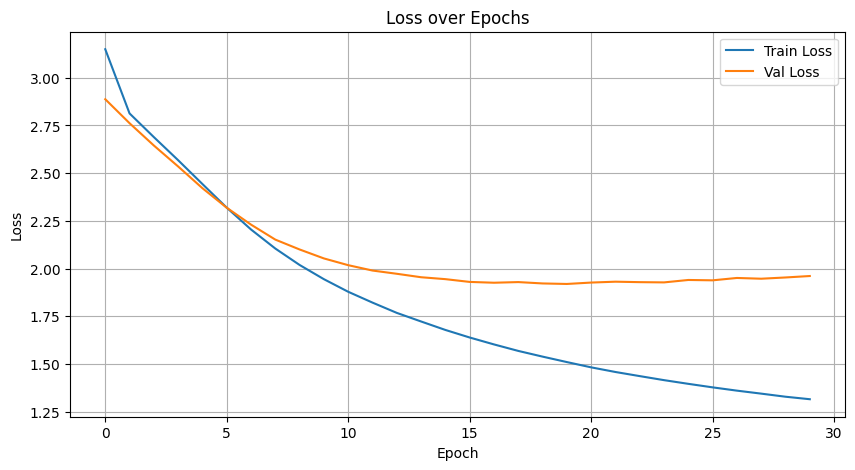

In [45]:
encoder = Encoder(
    vocab_size=MAX_VOCAB_SIZE,
    embedding_matrix=spanish_emb_matrix,
    lstm_layers=4,
    lstm_hidden_size=128)
decoder = Decoder(
    vocab_size=MAX_VOCAB_SIZE,
    embedding_matrix=english_emb_matrix,
    lstm_layers=4,
    lstm_hidden_size=128)
model = Seq2Seq(encoder, decoder).to('cuda')

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss()

EPOCHS = 100

train_loss_avg = list()
eval_loss_avg = list()

max_patience = 10
patience = 0
best_val_loss = float('inf')

for epoch in range(EPOCHS):

    model.train()
    epoch_loss = 0

    for encoder_input, decoder_input, target \
        in tqdm(train_dataloader, desc=f"Training: Epoch {epoch+1}/{EPOCHS}"):    
        encoder_input = encoder_input.to('cuda')
        decoder_input = decoder_input.to('cuda')
        target = target.to('cuda')

        optimizer.zero_grad()
        output = model(encoder_input, decoder_input)

        # reshape
        logits = output.reshape(-1, output.size(-1))
        targets = target.reshape(-1).long()

        loss = criterion(logits.cuda(), targets.cuda())
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss_avg.append(epoch_loss / len(train_dataloader))
    eval_loss, _ = evaluate(model, val_dataloader, criterion)
    eval_loss_avg.append(eval_loss)

    # save model if metric improves:
    if epoch == 0 or eval_loss < best_val_loss:
        patience = 0
        print(
            f'Val loss improved from {best_val_loss if epoch > 0 else "inf"} to {eval_loss}, '
            f'saving model at epoch {epoch+1}')
        torch.save(
            model.state_dict(),
            f"./{model.__class__.__name__}_best.pth")
        best_val_loss = eval_loss
    else:
        patience += 1
        if patience >= max_patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

    print(
        f"Epoch {epoch+1}/{EPOCHS}, Loss: {train_loss_avg[-1]:.4f}, "
        f"Val Loss: {eval_loss_avg[-1]:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(train_loss_avg)
plt.plot(eval_loss_avg)
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend(['Train Loss', 'Val Loss'])
plt.show()


In [55]:
# save word2idx mappings
import json
with open('word2idx_inputs.json', 'w') as f:
    json.dump(word2idx_inputs, f)
with open('word2idx_outputs.json', 'w') as f:
    json.dump(word2idx_outputs, f)
idx2word_target = {v:k for k, v in word2idx_outputs.items()}


In [61]:
# read json mappings
import json
with open('word2idx_inputs.json', 'r') as f:
    word2idx_inputs = json.load(f)
with open('word2idx_outputs.json', 'r') as f:
    word2idx_outputs = json.load(f)
idx2word_target = {v:k for k, v in word2idx_outputs.items()}

encoder = Encoder(
    vocab_size=MAX_VOCAB_SIZE,
    lstm_layers=4,
    lstm_hidden_size=128,
    embedding_matrix=spanish_emb_matrix,
)
decoder = Decoder(
    vocab_size=MAX_VOCAB_SIZE,
    lstm_layers=4,
    lstm_hidden_size=128,
    embedding_matrix=english_emb_matrix,
)
_model = Seq2Seq(
    encoder=encoder,
    decoder=decoder
).to('cuda')
_model.load_state_dict(torch.load(
    './Seq2Seq_best.pth', map_location='cuda'))

<All keys matched successfully>

In [85]:
def _translate_sentence(input_seq, model, word2idx_outputs, idx2word_target):
    # Se transforma la sequencia de entrada a los stados "h" y "c" de la LSTM
    # para enviar la primera vez al decoder"
    prev_state = model.encoder(input_seq.to('cuda'))

    # Se inicializa la secuencia de entrada al decoder como "<sos>"
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']
    target_seq_tensor = torch.from_numpy(target_seq.astype(np.int32))

    # Se obtiene el indice que finaliza la inferencia
    eos = word2idx_outputs['<eos>']
    
    output_sentence = []
    for _ in range(max_out_len):
        # Predicción del próximo elemento
        output, new_prev_state = model.decoder(target_seq_tensor.to('cuda'), prev_state)
        top1 = output.argmax(dim=-1)
        idx = top1.item()

        # Si es "end of sentece <eos>" se acaba
        if eos == idx:
            break

        # Transformar ídx a palabra
        word = ''        
        if idx > 0:
            word = idx2word_target[idx]
            output_sentence.append(word)

        # Actualizar los estados dado la ultimo prediccion
        prev_state = new_prev_state

        # Actualizar secuencia de entrada con la salida (re-alimentacion)
        target_seq_tensor = top1

    return ' '.join(output_sentence)


In [91]:
_model.eval()

with torch.no_grad():
    for input in [
        'feliz', 'buenos días', 'escribir ', 'tarde', 'ellos estan comiendo']:
        input_test = input.lower()
        integer_seq_test = input_tokenizer.texts_to_sequences([input_test])[0]
        encoder_sequence_test = pad_sequences([integer_seq_test], maxlen=max_input_len)

        encoder_sequence_test_tensor = torch.from_numpy(
        encoder_sequence_test.astype(np.int32)).long()

        translation = _translate_sentence(
            encoder_sequence_test_tensor, _model, word2idx_outputs, idx2word_target)
        print("Input test sentence:", input_test)
        print("Translation:", translation)



Input test sentence: feliz
Translation: a happy
Input test sentence: buenos días
Translation: a days
Input test sentence: escribir 
Translation: need drink
Input test sentence: tarde
Translation: waited late
Input test sentence: ellos estan comiendo
Translation: eating


# Conclusiones

Se logro comprender la arquitectura basica sec2sec y su aplicación en la traducción de texto y el preprocesamiento necesario para trabajar con este tipo de modelos. Se implementó un modelo de traducción de texto de espaniol a ingles utilizando LSTM y embeddings pre entrenados. Sin embargo, a pesar de presentar metricas de entrenamiento adecuadas, el modelo no logra traducir de manera adecuada todas las palabras ingresadas. Las palabras o frases que devuelve son coherentes y en algunos casos tienen relación con la entrada. Esto puede deberse a varias razones, entre ellas:
- La arquitectura del modelo es muy simple y no cuenta con mecanismos de atención que son el estado de arte en modelos de traducción modernos.
- La cantidad de datos de entrenamiento es limitada (se tuvo que limitar para evitar problemas de memoria y reducir el tiempo de entrenamiento), lo que dificulta que el modelo aprenda patrones complejos de traducción.
- La calidad y diversidad del conjunto de datos de entrenamiento puede no ser suficiente para cubrir la variedad de frases y estructuras gramaticales necesarias para una traducción efectiva.